# نشانه‌های planning در EC بین دیدن target و شروع joystick
**جلسه:** `amadeus08292019_a` (میمون A، ۵۷ نورون)

**سؤال:** در فاصله‌ی بین نمایش target landmark و joystick onset، آیا جمعیت نورون‌های EC اطلاعاتی درباره‌ی بردار آینده (فاصله و جهت) دارند؛ یعنی آیا میمون قبل از حرکت «برنامه‌ریزی» می‌کند؟

**ترتیب رویدادها در یک تریال** (Methods مقاله، صفحه‌ی Tasks/NTS):

`fixation → stim1on (لندمارک شروع) → target (≈+0.42s) → delay 0.4–1.4s → go cue → RT → joystick on → ... → joystick off`

- `delay` (به میکروثانیه) فاصله‌ی target تا go cue است و `rt` فاصله‌ی go cue تا joyon. این دو را در بخش ۱ با تطبیق سیگنال joystick بین تنسورهای هم‌تراز شده‌ی مختلف تأیید می‌کنیم.
- **نکته:** این‌که target حدود ۴۲۰ms بعد از stim1on ظاهر می‌شود یک **استنتاج** است (gocue − stim1on = delay + 0.42s؛ اسم `stim1on` و Fig. 1a هم با آن سازگارند). رویداد خام target onset در فایل‌ها نیست.
- مقاله (Fig. 3b–d) کدگذاری فاصله را در ۲۰۰ms قبل از joyon گزارش کرده است («onset coding»). این‌جا همین سؤال را با تفکیک زمانی دقیق‌تر و با چند کنترل بررسی می‌کنیم.

**داده:** `planning_preprocess.py` تنسورهای ۱ms را به bin های ۱۰ms (شمارش اسپایک) تبدیل و در `cache/` ذخیره می‌کند. مقادیر تنسور اصلی نرخ هستند: 1000 یعنی یک اسپایک در bin یک‌میلی‌ثانیه‌ای.

In [1]:
import subprocess, sys, warnings
import os.path as osp
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression, Ridge, LinearRegression
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score
warnings.filterwarnings("ignore")

SESSION = "amadeus08292019_a"
DATA_PATH = f"/media/naeem_md93/DRIVE/MNAV/EC/{SESSION}.mwk/"
CACHE = f"cache/{SESSION}_binned10ms.npz"
if not osp.exists(CACHE):
    subprocess.run([sys.executable, "planning_preprocess.py", SESSION], check=True)
d = np.load(CACHE)

cond = pd.DataFrame({k[5:]: d[k] for k in d.files if k.startswith("cond_")})
cond["dist"] = (cond.target - cond.curr).abs()
cond["dir"] = np.sign(cond.ta)
cond["prev_dir"] = cond.dir.shift(1).fillna(0)
cond["delay_s"] = cond.delay / 1e6

# MNAV trials (landmarks invisible), correct on the first attempt — same as the paper
base = ((cond.trial_type == 3) & (cond.attempt == 1)).values
keep = d["joyon"][base].mean((0, 1)) * 100 > 0.5   # drop neurons < 0.5 Hz
print("trials:", base.sum(), " neurons kept:", keep.sum(), "/", keep.size)

trials: 978  neurons kept: 53 / 57


## ۱. تأیید زمان رویدادها
سیگنال joystick (`hand_tensor_*`) در هر سه فایل همان سیگنال پیوسته است که فقط حول رویدادهای مختلف بریده شده. با پیدا کردن جابه‌جایی‌ای که دو برش را دقیقاً روی هم می‌اندازد، فاصله‌ی واقعی بین رویدادها به دست می‌آید.

In [2]:
def event_offset(a, ea, b, eb):
    # Time of event B in the frame of event A, found by exact matching of the joystick trace.
    seg = b[(eb > -0.5) & (eb < 0.5)]
    L = len(seg)
    win = np.lib.stride_tricks.sliding_window_view(a, L)
    k = np.argmin(((win - seg) ** 2).sum(1))
    return ea[k] + 0.5

idx = np.where(base)[0][:40]
H = {}
for ep in ["stim1on", "gocueon", "joyon"]:
    with h5py.File(f"{DATA_PATH}{SESSION}_neur_tensor_{ep}.mat", "r") as f:
        H[ep] = (f[f"hand_tensor_{ep}"][idx[0]:idx[-1] + 1][idx - idx[0]], f[f"{ep}/edges"][:, 0])

rows = []
for i, tr in enumerate(idx):
    g = event_offset(H["stim1on"][0][i], H["stim1on"][1], H["gocueon"][0][i], H["gocueon"][1])
    j = event_offset(H["gocueon"][0][i], H["gocueon"][1], H["joyon"][0][i], H["joyon"][1])
    rows.append((g - cond.delay_s[tr], j - cond.rt[tr]))
off = pd.DataFrame(rows, columns=["gocue_minus_delay (s, stim1on frame)", "joyon_minus_rt (s, gocue frame)"])
del H
off.describe().round(3)

,"gocue_minus_delay (s, stim1on frame)","joyon_minus_rt (s, gocue frame)"
count,40.000,40.000
mean,0.424,0.017
std,0.025,0.005
min,0.285,0.001
25%,0.419,0.015
50%,0.434,0.018
75%,0.435,0.021
max,0.453,0.025


هر دو اختلاف تقریباً ثابت‌اند: go cue = stim1on + **0.42s** + delay، و joyon ≈ go cue + rt (+۲۰ms). پس در این تحلیل target onset ≈ stim1on + 0.42s در نظر گرفته می‌شود.

## ۲. رفتار: delay و reaction time

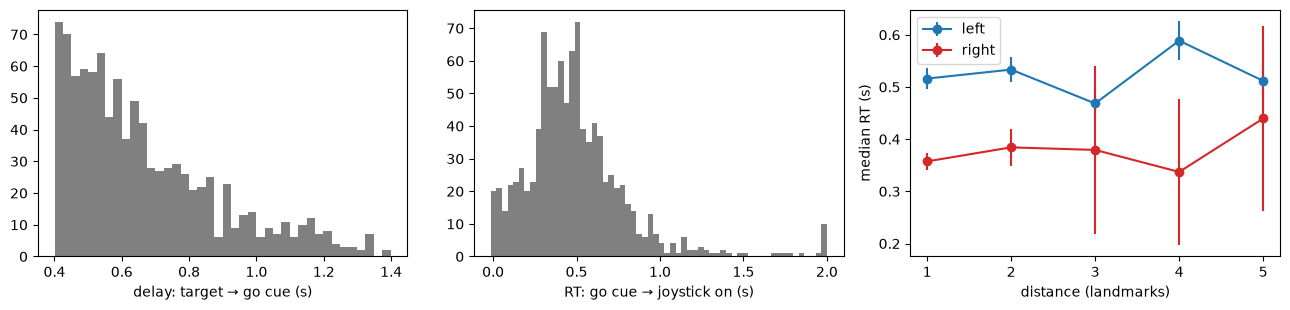

RT vs distance  Spearman: SignificanceResult(statistic=np.float64(0.04210229951169838), pvalue=np.float64(0.18832030323344093))
RT left vs right MWU: MannwhitneyuResult(statistic=np.float64(156496.0), pvalue=np.float64(6.147931505881878e-17))


In [3]:
b = cond[base]
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
ax[0].hist(b.delay_s, 40, color="gray"); ax[0].set_xlabel("delay: target → go cue (s)")
ax[1].hist(b.rt.clip(upper=2), 60, color="gray"); ax[1].set_xlabel("RT: go cue → joystick on (s)")
for dr, col in [(-1, "C0"), (1, "C3")]:
    m = b[b.dir == dr].groupby("dist").rt
    ax[2].errorbar(m.median().index, m.median(), yerr=m.sem(), color=col, marker="o", label="left" if dr < 0 else "right")
ax[2].set_xlabel("distance (landmarks)"); ax[2].set_ylabel("median RT (s)"); ax[2].legend()
plt.tight_layout(); plt.show()
print("RT vs distance  Spearman:", stats.spearmanr(b.dist, b.rt))
print("RT left vs right MWU:", stats.mannwhitneyu(b.rt[b.dir < 0], b.rt[b.dir > 0]))

## ۳. یک confound مهم: correction loop
بعد از خطا **همان شرط تکرار می‌شود** (`numrepeat` = شماره‌ی تکرار). پس در تریال‌های تکراری میمون شرط را قبل از دیدن لندمارک‌ها می‌داند و هر decoding قبل از target ممکن است حافظه‌ی تریال قبل باشد، نه planning. تحلیل اصلی را روی `numrepeat == 0` (اولین ارائه‌ی یک شرط جدید) انجام می‌دهیم.

In [4]:
b = cond[base]
print("P(previous trial had the same condition):", round((b.ta == cond.ta.shift(1)[base]).mean(), 3))
print(pd.crosstab(b.numrepeat.clip(upper=3), b.dir).rename(index={3: "3+"}))
clean = base & (cond.numrepeat == 0).values
print("clean trials (numrepeat==0):", clean.sum())

P(previous trial had the same condition): 0.499
dir        -1.0   1.0
numrepeat            
0.0         336   228
1.0          93   139
2.0          26    54
3+           34    68
clean trials (numrepeat==0): 564


## ۴. Decoding زمان‌مند جمعیت
در هر پنجره‌ی ۲۰۰ms، با cross-validation پنج‌تایی:
- **distance** (۱..۵): Ridge → همبستگی پیش‌بینی و مقدار واقعی (r)
- **direction**، **جهت تریال قبل**، **هویت start** و **target**: logistic → balanced accuracy
- **کنترل حرکتی:** همین decoding با ویژگی‌های سیگنال joystick (میانگین، شیب، انحراف معیار) به جای نورون‌ها

خط‌چین خاکستری = صدک ۹۵ توزیع null (برچسب‌های shuffle شده).

In [5]:
W = 0.2
def window(ep, t0, sel, w=W):
    t = d[ep + "_t"]; m = (t >= t0) & (t < t0 + w)
    X = np.sqrt(d[ep][sel][:, m][:, :, keep].sum(1).astype(float))
    h = d[ep + "_hand"][sel][:, m]
    Hf = np.c_[h.mean(1), h[:, -1] - h[:, 0], h.std(1)]
    return X, Hf

def score(X, y, kind, seed=0):
    if kind == "reg":
        cv = KFold(5, shuffle=True, random_state=seed)
        p = cross_val_predict(make_pipeline(StandardScaler(), Ridge(alpha=50)), X, y, cv=cv)
        return np.corrcoef(p, y)[0, 1]
    cv = StratifiedKFold(5, shuffle=True, random_state=seed)
    clf = make_pipeline(StandardScaler(), LogisticRegression(C=0.05, max_iter=500, class_weight="balanced"))
    return balanced_accuracy_score(y, cross_val_predict(clf, X, y, cv=cv))

VARS = {"distance": ("reg", "dist"), "direction": ("clf", "dir"), "prev. trial dir": ("clf", "prev_dir"),
        "start image": ("clf", "curr"), "target image": ("clf", "target")}
GRID = {"stim1on": np.arange(-0.6, 0.71, 0.1), "gocueon": np.arange(-0.8, 0.11, 0.1), "joyon": np.arange(-0.8, 0.01, 0.1)}

def run(sel, n_null=10, seed=0):
    rng = np.random.default_rng(seed); c = cond[sel]; rows = []
    for ep, grid in GRID.items():
        for t0 in grid:
            X, Hf = window(ep, t0, sel)
            for name, (kind, col) in VARS.items():
                y = c[col].values
                null = [score(X, rng.permutation(y), kind) for _ in range(n_null)]
                rows.append((ep, t0 + W / 2, name, "neural", score(X, y, kind), np.quantile(null, .95)))
                if name in ("distance", "direction"):
                    rows.append((ep, t0 + W / 2, name, "joystick", score(Hf, y, kind), np.nan))
    return pd.DataFrame(rows, columns=["ep", "t", "var", "src", "score", "null95"])

res = run(clean)

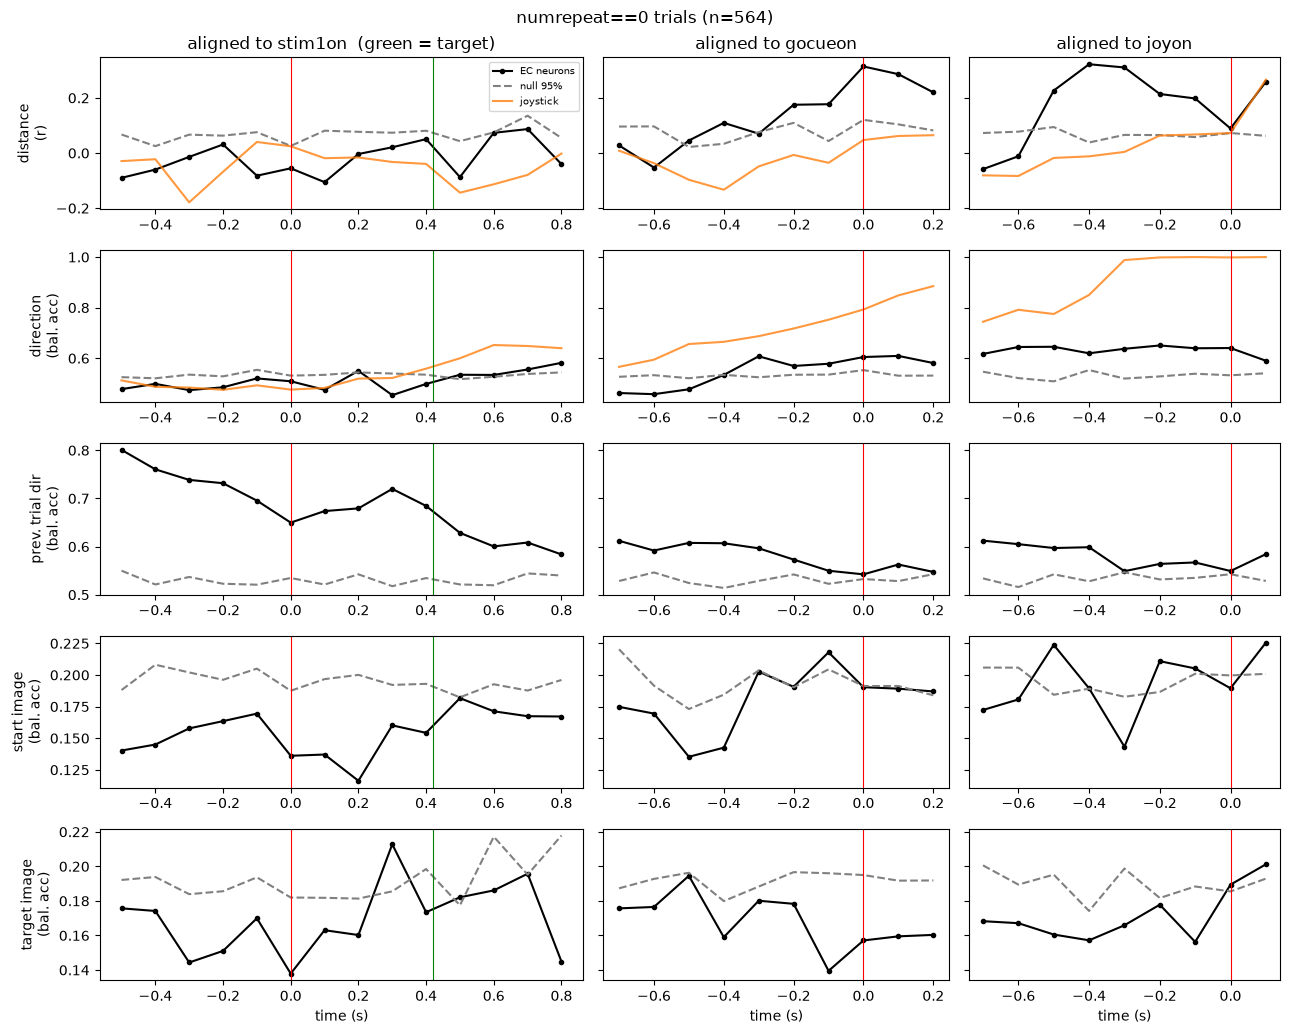

In [6]:
def plot_res(res, title):
    fig, ax = plt.subplots(len(VARS), 3, figsize=(13, 2.1 * len(VARS)), sharey="row",
                           gridspec_kw=dict(width_ratios=[len(g) for g in GRID.values()]))
    for i, v in enumerate(VARS):
        for j, ep in enumerate(GRID):
            a = ax[i, j]; r = res[(res["var"] == v) & (res.ep == ep)]
            n, h = r[r.src == "neural"], r[r.src == "joystick"]
            a.plot(n.t, n.score, "k-o", ms=3, label="EC neurons")
            a.plot(n.t, n.null95, "--", color="gray", label="null 95%")
            if len(h): a.plot(h.t, h.score, "-", color="C1", alpha=.8, label="joystick")
            a.axvline(0, color="r", lw=.8)
            if ep == "stim1on": a.axvline(0.42, color="g", lw=.8)
            if i == 0: a.set_title(f"aligned to {ep}" + ("  (green = target)" if ep == "stim1on" else ""))
            if j == 0: a.set_ylabel(v + ("\n(r)" if v == "distance" else "\n(bal. acc)"))
            if i == len(VARS) - 1: a.set_xlabel("time (s)")
    ax[0, 0].legend(fontsize=7); fig.suptitle(title); plt.tight_layout(); plt.show()

plot_res(res, f"numrepeat==0 trials (n={clean.sum()})")

## ۵. کنترل: آیا سیگنال‌ها فقط بازتاب حرکت زودهنگام joystick هستند؟
از هر نورون، بخشی از فعالیت را که با سیگنال joystick در همان پنجره به‌صورت خطی قابل توضیح است حذف می‌کنیم و دوباره decode می‌کنیم.

⚠️ وقتی خود joystick جهت را تقریباً کامل مشخص کند (نزدیک joyon)، این residual کردن اطلاعات جهت را «بیش از حد» حذف می‌کند و دقت حتی زیر شانس می‌رود؛ پس آن پنجره‌ها برای جهت قابل تفسیر نیستند.

In [7]:
def resid(X, Hf):
    return X - LinearRegression().fit(Hf, X).predict(Hf)

c = cond[clean]; rows = []
for ep, t0 in [("stim1on", -0.5), ("stim1on", 0.5), ("gocueon", -0.6), ("gocueon", -0.4), ("gocueon", -0.2),
               ("gocueon", 0.0), ("joyon", -0.6), ("joyon", -0.4), ("joyon", -0.2)]:
    X, Hf = window(ep, t0, clean)
    rows.append(dict(window=f"{ep} [{t0:+.1f},{t0 + W:+.1f}]",
                     dir_neural=score(X, c.dir.values, "clf"), dir_joystick=score(Hf, c.dir.values, "clf"),
                     dir_neural_minus_joy=score(resid(X, Hf), c.dir.values, "clf"),
                     dist_neural=score(X, c.dist.values, "reg"), dist_joystick=score(Hf, c.dist.values, "reg"),
                     dist_neural_minus_joy=score(resid(X, Hf), c.dist.values, "reg")))
pd.DataFrame(rows).set_index("window").round(3)

,dir_neural,dir_joystick,dir_neural_minus_joy,dist_neural,dist_joystick,dist_neural_minus_joy
window,,,,,,
"stim1on [-0.5,-0.3]",0.499,0.487,0.509,-0.060,-0.022,-0.077
"stim1on [+0.5,+0.7]",0.534,0.652,0.540,0.073,-0.113,0.069
"gocueon [-0.6,-0.4]",0.477,0.656,0.475,0.046,-0.097,0.052
"gocueon [-0.4,-0.2]",0.608,0.687,0.567,0.070,-0.048,0.069
"gocueon [-0.2,+0.0]",0.578,0.752,0.501,0.177,-0.035,0.172
"gocueon [+0.0,+0.2]",0.609,0.849,0.497,0.286,0.062,0.265
"joyon [-0.6,-0.4]",0.645,0.775,0.581,0.227,-0.018,0.228
"joyon [-0.4,-0.2]",0.637,0.988,0.438,0.310,0.004,0.317
"joyon [-0.2,+0.0]",0.640,1.000,0.276,0.198,0.067,0.189


## ۶. هم‌ترازی با target onset
پنجره‌ها را نسبت به target (stim1on + 0.42s) می‌چینیم و در هر پنجره فقط تریال‌هایی را نگه می‌داریم که go cue آن‌ها **بعد از** پایان پنجره است؛ پس هیچ داده‌ای از بعد از go cue وارد نمی‌شود. هرچه پنجره دیرتر باشد تعداد تریال کمتر است.

numrepeat==0
 t_from_target   n      r  null95
          -0.3 564 -0.067   0.074
          -0.2 564 -0.021   0.084
          -0.1 564  0.093   0.065
          -0.0 564  0.017   0.074
           0.1 564 -0.053   0.091
           0.2 564  0.140   0.097
           0.3 564  0.102   0.091
           0.4 413 -0.006   0.099
           0.5 275  0.069   0.158
           0.6 185  0.157   0.140
           0.7 124 -0.141   0.196
           0.8  90 -0.029   0.212
           0.9  59  0.333   0.301
           1.0  40  0.460   0.331


all 1-attempt
 t_from_target   n      r  null95
          -0.3 978  0.063   0.065
          -0.2 978  0.077   0.062
          -0.1 978  0.016   0.053
          -0.0 978  0.014   0.071
           0.1 978 -0.063   0.074
           0.2 978 -0.006   0.073
           0.3 978  0.110   0.063
           0.4 718  0.072   0.069
           0.5 496  0.127   0.074
           0.6 339  0.131   0.121
           0.7 230 -0.030   0.111
           0.8 156  0.055   0.163
           0.9  97  0.268   0.159
           1.0  64  0.312   0.232


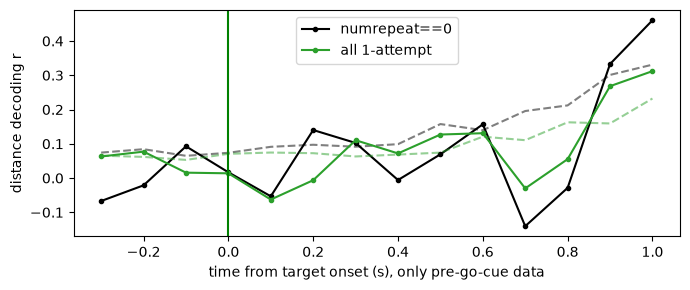

In [8]:
T_TARGET = 0.42
def target_aligned(sel, n_null=100, seed=2):
    rng = np.random.default_rng(seed); t = d["stim1on_t"]; rows = []
    for w0 in np.arange(-0.4, 1.01, 0.1):
        s = sel & (cond.delay_s.values > w0 + W)
        m = (t >= T_TARGET + w0) & (t < T_TARGET + w0 + W)
        if s.sum() < 30 or not m.any(): continue
        X = np.sqrt(d["stim1on"][s][:, m][:, :, keep].sum(1).astype(float)); y = cond.dist.values[s]
        null = [score(X, rng.permutation(y), "reg") for _ in range(n_null)]
        rows.append((w0 + W / 2, s.sum(), score(X, y, "reg"), np.quantile(null, .95)))
    return pd.DataFrame(rows, columns=["t_from_target", "n", "r", "null95"])

fig, ax = plt.subplots(figsize=(7, 3))
for lab, sel, col in [("numrepeat==0", clean, "k"), ("all 1-attempt", base, "C2")]:
    ta_ = target_aligned(sel)
    ax.plot(ta_.t_from_target, ta_.r, "-o", color=col, ms=3, label=lab)
    ax.plot(ta_.t_from_target, ta_.null95, "--", color=col, alpha=.5)
    print(lab); print(ta_.round(3).to_string(index=False))
ax.axvline(0, color="g"); ax.set_xlabel("time from target onset (s), only pre-go-cue data"); ax.set_ylabel("distance decoding r")
ax.legend(); plt.tight_layout(); plt.show()

## ۷. آیا شدت سیگنال planning رفتار تریال‌به‌تریال را پیش‌بینی می‌کند؟
خروجی cross-validated دیکودر فاصله (پنجره‌ی ۴۰۰ms) را **داخل هر شرط** (همان ta) مرکز می‌کنیم و با فاصله‌ی تولیدشده‌ی نسبی (tp/ta) و RT مقایسه می‌کنیم. اگر EC قبل از حرکت «برنامه» را بسازد، انتظار داریم readout بزرگ‌تر با حرکت بلندتر همراه باشد.

In [9]:
rows = []
for lab, sel in [("numrepeat==0", clean), ("all 1-attempt", base)]:
    c = cond[sel].reset_index(drop=True)
    for ep, t0 in [("gocueon", -0.2), ("joyon", -0.5)]:
        t = d[ep + "_t"]; m = (t >= t0) & (t < t0 + 0.4)
        X = np.sqrt(d[ep][sel][:, m][:, :, keep].sum(1).astype(float))
        p = cross_val_predict(make_pipeline(StandardScaler(), Ridge(alpha=50)), X, c.dist.values,
                              cv=KFold(5, shuffle=True, random_state=0))
        df = pd.DataFrame({"p": p, "tp_rel": c.tp.abs() / c.ta.abs(), "rt": c.rt, "ta": c.ta})
        for k in ["p", "tp_rel", "rt"]:
            df[k] -= df.groupby("ta")[k].transform("mean")
        a, bb = stats.spearmanr(df.p, df.tp_rel), stats.spearmanr(df.p, df.rt)
        rows.append(dict(trials=lab, window=f"{ep} [{t0:+.1f},{t0 + .4:+.1f}]", dist_r=np.corrcoef(p, c.dist)[0, 1],
                         rho_tp=a[0], p_tp=a[1], rho_rt=bb[0], p_rt=bb[1]))
pd.DataFrame(rows).round(3)

,trials,window,dist_r,rho_tp,p_tp,rho_rt,p_rt
0,numrepeat==0,"gocueon [-0.2,+0.2]",0.342,-0.001,0.987,0.051,0.222
1,numrepeat==0,"joyon [-0.5,-0.1]",0.391,0.075,0.075,-0.008,0.845
2,all 1-attempt,"gocueon [-0.2,+0.2]",0.273,-0.014,0.669,0.020,0.524
3,all 1-attempt,"joyon [-0.5,-0.1]",0.355,0.072,0.024,0.011,0.739


## ۸. جمع‌بندی (این جلسه)
1. **فاصله‌ی هدف (distance) قبل از حرکت در EC کد می‌شود؛ این نشانه‌ی planning است.** روی تریال‌های تمیز (`numrepeat==0`)، قبل از stim1on و در همان لحظه‌ی دیدن target در حد شانس است. بعد از target کمی بالا می‌رود (r≈0.1–0.15، مرزی) و از حدود ۲۰۰ms قبل از go cue تا قبل از joyon قوی می‌شود (r≈0.18–0.32 در پنجره‌های ۲۰۰ms و تا 0.39 در پنجره‌ی ۴۰۰ms). سیگنال joystick هیچ اطلاعاتی از فاصله ندارد و حذف اثر آن سیگنال نورونی را تغییر نمی‌دهد؛ پس این سیگنال حرکتی نیست. این با «onset coding» در Fig. 3b–d مقاله سازگار است.
2. **جهت (direction) شاهد محکمی نیست.** joystick خودش از حدود ۳۰۰–۴۰۰ms قبل از go cue به سمت جهت درست drift دارد (پیش‌آمادگی حرکتی). بعد از حذف اثر joystick فقط اثر کوچکی باقی می‌ماند (حدود ۰.۵۷–۰.۵۸ در gocue[-0.4,-0.2] و joyon[-0.6,-0.4]).
3. **هویت تصاویر** (start و target) تقریباً در حد شانس است. پس سیگنال فاصله «بازنمایی بینایی تصویر» نیست، که با ادعای مقاله هم‌خوان است.
4. **حافظه‌ی تریال قبل:** جهت تریال قبلی قبل از stim1on قوی decode می‌شود. اگر تریال‌های correction کنار گذاشته نشوند، این حافظه با «planning» اشتباه گرفته می‌شود.
5. **رابطه با رفتار:** ضعیف است. readout فاصله در پنجره‌ی joyon[-0.5,-0.1] با tp/ta داخل هر شرط ρ≈0.07 دارد (روی تریال‌های تمیز p=0.075؛ روی همه‌ی تریال‌ها p=0.024، که correction loop روی آن اثر دارد). با RT هیچ رابطه‌ای ندارد.
6. **زمان‌بندی:** فاصله بیشتر نزدیک go cue ظاهر می‌شود تا بلافاصله بعد از target. یعنی ممکن است planning دیر و نزدیک زمان حرکت انجام شود، یا محاسبه کند باشد. برای قطعی کردن این به چند جلسه نیاز است (تعداد تریال‌های delay بلند کم است).

**محدودیت‌ها:** فقط یک جلسه است (۵۳ نورون). target onset استنتاج‌شده است، نه رویداد خام. drift joystick قبل از go cue کامل کنترل نشده است.